# Cognitive Mobility Index

Operationalises the **upgrading / alignment / downgrading** phenomenon in AR Q&A pairs.

The four substantive labels are placed on an ordinal cognitive-demand scale:

| Label | Rank | Court role |
|---|---|---|
| FEIT | 1 | Database |
| CAU  | 2 | Analyst |
| OOR  | 3 | Judge |
| ADV  | 4 | Advisor |

For each matched Q×A pair the **cognitive mobility score (CMS)** is defined as:

$$\text{CMS} = \text{rank}(A) - \text{rank}(Q) \in \{-3, \ldots, +3\}$$

- **CMS < 0** — downgrading: Court reduces cognitive engagement relative to what was asked  
- **CMS = 0** — alignment: Court matches the question's cognitive level  
- **CMS > 0** — upgrading: Court goes beyond what was asked  
- **DEFL** — treated separately; modelled as a binary outcome (engaged vs. refused)

Sections:
1. Data preparation and CMS computation
2. Descriptive distribution of CMS
3. CMS by policy domain and report type
4. Ordinal regression: what predicts upgrading vs. downgrading?
5. Text-level predictors: question length and confidence as CMS predictors
6. DEFL as a separate binary outcome
7. OOR deep-dive: anatomy of downgraded evaluative questions

In [1]:
import sys
sys.path.insert(0, '.')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from paths import ANNOTATED_Q_CSV, ANNOTATED_A_CSV, METADATA_CSV, DATA_DIR

RANK = {'FEIT': 1, 'CAU': 2, 'OOR': 3, 'ADV': 4}
LABEL_ORDER = ['FEIT', 'CAU', 'OOR', 'ADV']
PALETTE = {'downgrade': '#d62728', 'aligned': '#2ca02c', 'upgrade': '#1f77b4'}

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Data preparation

In [2]:
q = pd.read_csv(ANNOTATED_Q_CSV, sep='\t')
a = pd.read_csv(ANNOTATED_A_CSV, sep='\t')
meta = pd.read_csv(METADATA_CSV, sep='\t')
report_meta = pd.read_csv(DATA_DIR / 'report_metadata.csv', sep='\t')

# Merge Q and A on document + question number
df = q.merge(
    a[['src_id', 'vraag_nr', 'llm_label', 'llm_confidence', 'llm_reasoning']]
      .rename(columns={'llm_label': 'a_label',
                       'llm_confidence': 'a_conf',
                       'llm_reasoning': 'a_reasoning'}),
    on=['src_id', 'vraag_nr'],
    how='inner'
).rename(columns={'llm_label': 'q_label',
                  'llm_confidence': 'q_conf',
                  'llm_reasoning': 'q_reasoning'})

# Attach document metadata
df = df.merge(meta[['src_id', 'commissie', 'n_vragen']], on='src_id', how='left')

# Attach report metadata (domain, report_type)
df = df.merge(
    report_meta[['rapport_titel', 'category', 'report_type']],
    on='rapport_titel', how='left'
)

# Question length
df['q_len'] = df['vraag'].fillna('').apply(lambda x: len(str(x).split()))
df['a_len'] = df['antwoord'].fillna('').apply(lambda x: len(str(x).split()))

print(f'Matched pairs: {len(df):,}')
print(f'Q labels: {df["q_label"].value_counts().to_dict()}')
print(f'A labels: {df["a_label"].value_counts().to_dict()}')

Matched pairs: 1,725
Q labels: {'OOR': 603, 'FEIT': 537, 'CAU': 295, 'ADV': 282, '?': 8}
A labels: {'DEFL': 525, 'FEIT': 505, 'OOR': 368, 'ADV': 247, 'CAU': 75, '?': 5}


In [3]:
# Separate DEFL from the substantive subset
df['is_defl'] = df['a_label'] == 'DEFL'

# Substantive subset: both Q and A are in the ranked label set
sub = df[
    df['q_label'].isin(RANK) &
    df['a_label'].isin(RANK)
].copy()

sub['q_rank'] = sub['q_label'].map(RANK)
sub['a_rank'] = sub['a_label'].map(RANK)
sub['cms']    = sub['a_rank'] - sub['q_rank']
sub['direction'] = pd.cut(
    sub['cms'],
    bins=[-4, -0.5, 0.5, 4],
    labels=['downgrade', 'aligned', 'upgrade']
)

print(f'Substantive pairs (no DEFL): {len(sub):,}')
print(sub['direction'].value_counts())
print(f'\nMean CMS: {sub["cms"].mean():.3f}  (positive = net upgrading)')

Substantive pairs (no DEFL): 1,190
direction
aligned      690
downgrade    275
upgrade      225
Name: count, dtype: int64

Mean CMS: -0.087  (positive = net upgrading)


## 2. Descriptive distribution of CMS

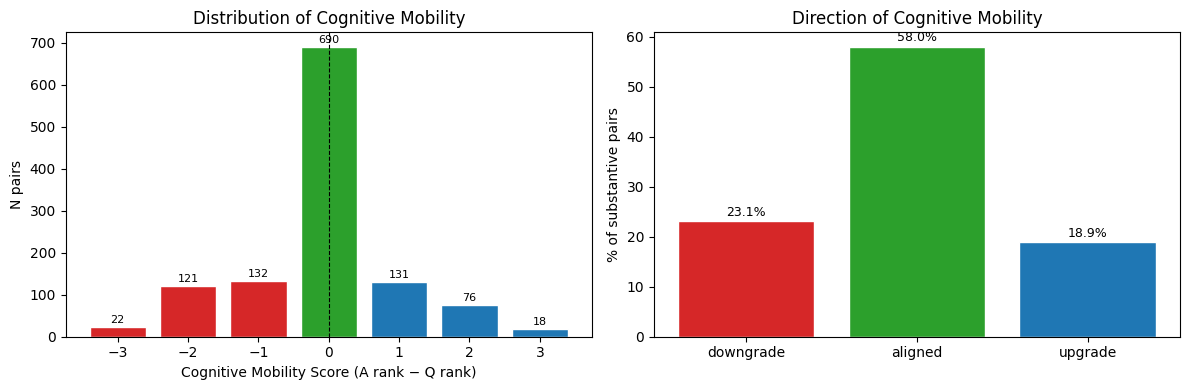


Summary:
  downgrade :  275 (23.1%)
  aligned   :  690 (58.0%)
  upgrade   :  225 (18.9%)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of CMS
cms_counts = sub['cms'].value_counts().sort_index()
colors = ['#d62728' if v < 0 else '#2ca02c' if v == 0 else '#1f77b4'
          for v in cms_counts.index]
axes[0].bar(cms_counts.index, cms_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Cognitive Mobility Score (A rank − Q rank)')
axes[0].set_ylabel('N pairs')
axes[0].set_title('Distribution of Cognitive Mobility')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(1))

# Add text labels
for v, n in zip(cms_counts.index, cms_counts.values):
    axes[0].text(v, n + 5, str(n), ha='center', va='bottom', fontsize=8)

# Right: direction summary
dir_counts = sub['direction'].value_counts().reindex(['downgrade', 'aligned', 'upgrade'])
dir_pct = dir_counts / len(sub) * 100
bar_colors = [PALETTE[d] for d in dir_pct.index]
bars = axes[1].bar(dir_pct.index, dir_pct.values, color=bar_colors, edgecolor='white')
axes[1].set_ylabel('% of substantive pairs')
axes[1].set_title('Direction of Cognitive Mobility')
for bar, pct in zip(bars, dir_pct.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print('\nSummary:')
for d in ['downgrade', 'aligned', 'upgrade']:
    n = dir_counts[d]
    print(f'  {d:10s}: {n:4d} ({n/len(sub)*100:.1f}%)')

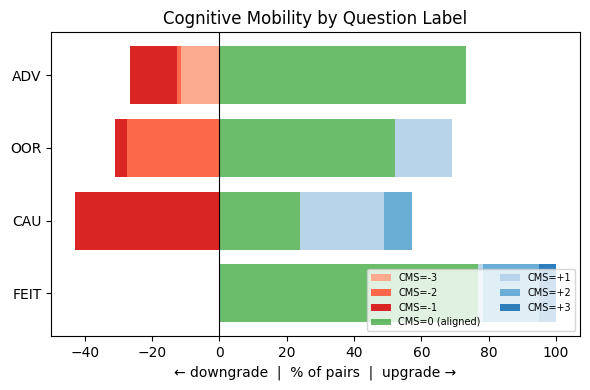

In [6]:
# CMS by question label — shows which demand types are most prone to down/upgrading
fig, ax = plt.subplots(figsize=(6, 4))

cms_by_q = sub.groupby(['q_label', 'cms']).size().unstack(fill_value=0)
cms_by_q = cms_by_q.loc[LABEL_ORDER, :]
cms_pct = cms_by_q.div(cms_by_q.sum(axis=1), axis=0) * 100

# Diverging bar: negatives left, zero centre, positives right
neg_cols = [c for c in cms_pct.columns if c < 0]
pos_cols = [c for c in cms_pct.columns if c > 0]
zero_col = 0 if 0 in cms_pct.columns else []

cmap_neg = plt.cm.Reds
cmap_pos = plt.cm.Blues

y = np.arange(len(LABEL_ORDER))
left_neg = np.zeros(len(LABEL_ORDER))
left_pos = np.zeros(len(LABEL_ORDER))

for i, c in enumerate(sorted(neg_cols)):
    vals = cms_pct[c].values
    ax.barh(y, -vals, left=-left_neg, color=cmap_neg(0.3 + 0.2*i), label=f'CMS={c}')
    left_neg += vals

if isinstance(zero_col, int):
    vals = cms_pct[zero_col].values
    ax.barh(y, vals, left=left_pos, color='#2ca02c', alpha=0.7, label='CMS=0 (aligned)')
    left_pos += vals

for i, c in enumerate(sorted(pos_cols)):
    vals = cms_pct[c].values
    ax.barh(y, vals, left=left_pos, color=cmap_pos(0.3 + 0.2*i), label=f'CMS=+{c}')
    left_pos += vals

ax.set_yticks(y)
ax.set_yticklabels(LABEL_ORDER)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('← downgrade  |  % of pairs  |  upgrade →')
ax.set_title('Cognitive Mobility by Question Label')
ax.legend(loc='lower right', fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

## 3. CMS by policy domain and report type

In [7]:
# Mean CMS and direction rates by policy domain (domains N >= 30 in substantive subset)
domain_grp = sub.groupby('category').agg(
    N=('cms', 'count'),
    mean_cms=('cms', 'mean'),
    pct_down=('direction', lambda x: (x == 'downgrade').mean() * 100),
    pct_aligned=('direction', lambda x: (x == 'aligned').mean() * 100),
    pct_up=('direction', lambda x: (x == 'upgrade').mean() * 100),
).query('N >= 30').sort_values('mean_cms')

display(domain_grp.round(1))

,N,mean_cms,pct_down,pct_aligned,pct_up
category,,,,,
BZ,47,-0.400,25.500,68.100,6.400
SZW,40,-0.200,27.500,52.500,20.000
FIN,106,-0.200,24.500,57.500,17.900
RIJKS,110,-0.200,24.500,60.900,14.500
IenW,37,-0.200,24.300,56.800,18.900
BZK,86,-0.100,26.700,53.500,19.800
DEF,246,-0.100,22.000,60.600,17.500
JenV,102,-0.000,24.500,54.900,20.600
OCW,115,0.100,14.800,67.000,18.300


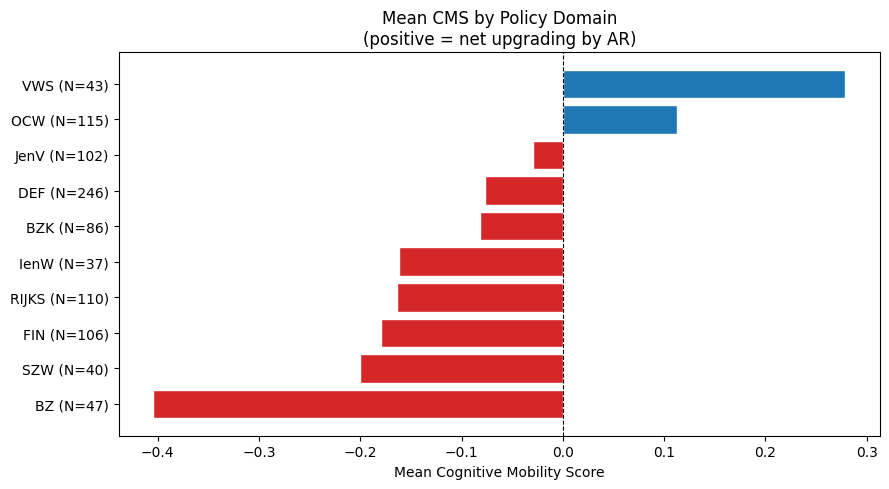

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
domains = domain_grp.index
y = np.arange(len(domains))

ax.barh(y, domain_grp['mean_cms'], color=[
    '#d62728' if v < 0 else '#2ca02c' if v == 0 else '#1f77b4'
    for v in domain_grp['mean_cms']
], edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels([f"{d} (N={domain_grp.loc[d,'N']})" for d in domains])
ax.set_xlabel('Mean Cognitive Mobility Score')
ax.set_title('Mean CMS by Policy Domain\n(positive = net upgrading by AR)')
plt.tight_layout()
plt.show()

In [9]:
# Report type
rt_grp = sub.groupby('report_type').agg(
    N=('cms', 'count'),
    mean_cms=('cms', 'mean'),
    median_cms=('cms', 'median'),
    pct_down=('direction', lambda x: (x == 'downgrade').mean() * 100),
    pct_aligned=('direction', lambda x: (x == 'aligned').mean() * 100),
    pct_up=('direction', lambda x: (x == 'upgrade').mean() * 100),
).dropna()

display(rt_grp.round(2))

# Kruskal-Wallis test
groups = [sub[sub['report_type'] == rt]['cms'].dropna() for rt in sub['report_type'].dropna().unique()]
h, p = stats.kruskal(*groups)
print(f'\nKruskal-Wallis H={h:.2f}, p={p:.4f}')

,N,mean_cms,median_cms,pct_down,pct_aligned,pct_up
report_type,,,,,,
overig,28,-0.390,0.000,28.570,60.710,10.710
thematisch,396,-0.220,0.000,28.280,55.810,15.910
verantwoordingsonderzoek,766,-0.010,0.000,20.230,59.010,20.760



Kruskal-Wallis H=12.66, p=0.0018


## 4. Ordinal regression: predictors of CMS

In [10]:
try:
    from statsmodels.miscmodels.ordinal_model import OrderedModel
    HAS_ORDERED = True
except ImportError:
    HAS_ORDERED = False
    print('statsmodels OrderedModel not available; falling back to OLS on CMS')

import statsmodels.formula.api as smf

reg = sub.copy()

# Encode predictors
reg['q_label_cat'] = pd.Categorical(reg['q_label'], categories=LABEL_ORDER)
reg['report_type_bin'] = (reg['report_type'] == 'verantwoordingsonderzoek').astype(int)
reg['q_conf_H'] = (reg['q_conf'] == 'H').astype(int)
reg['log_q_len'] = np.log1p(reg['q_len'])

# OLS on CMS (interpretable, well-behaved)
ols_formula = 'cms ~ C(q_label, Treatment("FEIT")) + report_type_bin + log_q_len + q_conf_H'
ols = smf.ols(ols_formula, data=reg.dropna(subset=['cms', 'report_type', 'q_len'])).fit(
    cov_type='cluster', cov_kwds={'groups': reg.dropna(subset=['cms', 'report_type', 'q_len'])['src_id']}
)
print(ols.summary2())

                           Results: Ordinary least squares
Model:                     OLS                    Adj. R-squared:           0.166    
Dependent Variable:        cms                    AIC:                      3364.8324
Date:                      2026-03-25 13:39       BIC:                      3400.4043
No. Observations:          1190                   Log-Likelihood:           -1675.4  
Df Model:                  6                      F-statistic:              34.65    
Df Residuals:              1183                   Prob (F-statistic):       9.87e-27 
R-squared:                 0.170                  Scale:                    0.98398  
-------------------------------------------------------------------------------------
                                      Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------------------------------
Intercept                             0.0405   0.1694   0.2390 0.8111 -0.2915  0.

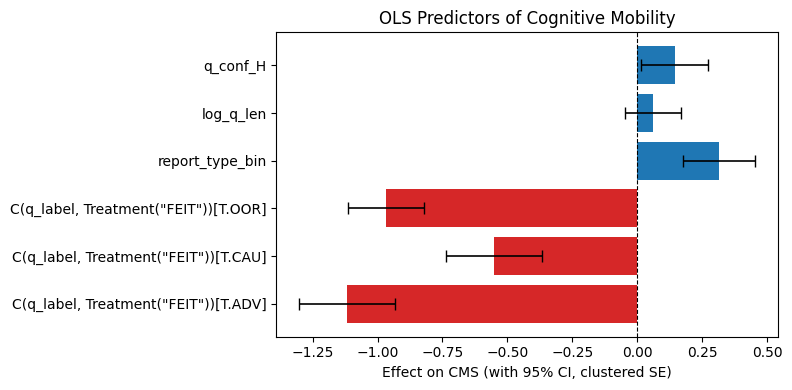

In [11]:
# Visualise OLS coefficients
coef = ols.params.drop('Intercept')
ci   = ols.conf_int().drop('Intercept')

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(coef))
ax.barh(y, coef.values,
        xerr=[(coef.values - ci[0].values), (ci[1].values - coef.values)],
        color=['#d62728' if v < 0 else '#1f77b4' for v in coef.values],
        capsize=4, error_kw={'linewidth': 1.2})
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels(coef.index)
ax.set_xlabel('Effect on CMS (with 95% CI, clustered SE)')
ax.set_title('OLS Predictors of Cognitive Mobility')
plt.tight_layout()
plt.show()

## 5. Question length and confidence as CMS predictors

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Question length by direction — use explicit data ordering instead of order= kwarg
dir_order = ['downgrade', 'aligned', 'upgrade']
data_len = [sub[sub['direction'] == d]['q_len'].dropna() for d in dir_order]
axes[0].boxplot(data_len, labels=dir_order,
                boxprops=dict(color='steelblue'),
                medianprops=dict(color='firebrick', linewidth=2))
axes[0].set_title('Question length by CMS direction')
axes[0].set_xlabel('')
axes[0].set_ylabel('Words')

# Q confidence by direction
conf_dir = sub.groupby(['direction', 'q_conf']).size().unstack(fill_value=0)
conf_dir_pct = conf_dir.div(conf_dir.sum(axis=1), axis=0) * 100
conf_dir_pct.loc[['downgrade', 'aligned', 'upgrade']].plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#2ca02c', '#ff7f0e', '#d62728'], edgecolor='white'
)
axes[1].set_title('Annotator confidence by CMS direction')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Confidence', loc='upper right')

plt.tight_layout()
plt.show()

# Kruskal-Wallis for question length
groups_len = [sub[sub['direction'] == d]['q_len'] for d in dir_order]
h, p = stats.kruskal(*groups_len)
print(f'Kruskal-Wallis (q_len by direction): H={h:.2f}, p={p:.4f}')

## 6. DEFL as a separate binary outcome

In [13]:
# DEFL rates by Q label, domain, and report type
print('=== DEFL rate by Q label ===')
defl_by_q = df[df['q_label'].isin(RANK)].groupby('q_label')['is_defl'].agg(['mean', 'sum', 'count'])
defl_by_q['mean'] *= 100
defl_by_q.columns = ['DEFL %', 'DEFL N', 'Total N']
display(defl_by_q.loc[LABEL_ORDER].round(1))

print('\n=== DEFL rate by domain (N >= 30) ===')
defl_by_dom = df[df['q_label'].isin(RANK)].groupby('category')['is_defl'].agg(['mean','count'])
defl_by_dom.columns = ['DEFL %', 'N']
defl_by_dom['DEFL %'] *= 100
display(defl_by_dom[defl_by_dom['N'] >= 30].sort_values('DEFL %', ascending=False).round(1))

=== DEFL rate by Q label ===


,DEFL %,DEFL N,Total N
q_label,,,
FEIT,33.500,180,537
CAU,28.100,83,295
OOR,28.200,170,603
ADV,31.600,89,282



=== DEFL rate by domain (N >= 30) ===


,DEFL %,N
category,,
BZK,41.600,149
JenV,35.800,159
INTER,32.500,40
FIN,31.600,155
VWS,30.600,62
OCW,30.300,165
EZK,30.000,30
DEF,27.500,342
IenW,26.000,50


In [14]:
# Logistic regression: predictors of DEFL
log_df = df[df['q_label'].isin(RANK)].copy()
log_df['is_defl'] = log_df['is_defl'].astype(int)  # ensure int for statsmodels
log_df['q_label_cat'] = pd.Categorical(log_df['q_label'], categories=LABEL_ORDER)
log_df['report_type_bin'] = (log_df['report_type'] == 'verantwoordingsonderzoek').astype(int)
log_df['log_q_len'] = np.log1p(log_df['q_len'])

logit = smf.logit(
    'is_defl ~ C(q_label, Treatment("FEIT")) + report_type_bin + log_q_len',
    data=log_df.dropna(subset=['is_defl', 'report_type', 'q_len'])
).fit(cov_type='cluster',
      cov_kwds={'groups': log_df.dropna(subset=['is_defl', 'report_type', 'q_len'])['src_id']},
      disp=False)

print(logit.summary2())
print('\n--- Odds ratios ---')
print(np.exp(logit.params).round(3))

## 7. OOR deep-dive: anatomy of downgraded evaluative questions

For OOR questions specifically, compare the three response paths: OOR→OOR (aligned), OOR→FEIT (downgraded), OOR→DEFL (refused).

OOR response path distribution:
response_path
aligned (OOR→OOR)        226
refused (OOR→DEFL)       170
downgraded (OOR→FEIT)    119
upgraded (OOR→ADV)        72
downgraded (OOR→CAU)      15
other                      1
Name: count, dtype: int64



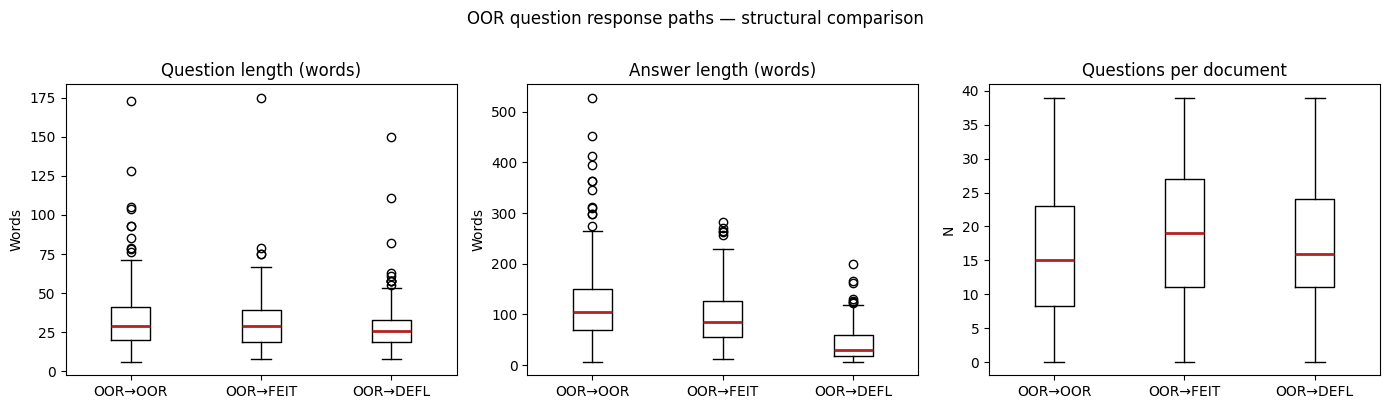

Kruskal-Wallis (q_len): H=4.56, p=0.1025
Kruskal-Wallis (a_len): H=165.58, p=0.0000


In [15]:
oor = df[df['q_label'] == 'OOR'].copy()
oor['response_path'] = oor['a_label'].map({
    'OOR':  'aligned (OOR→OOR)',
    'FEIT': 'downgraded (OOR→FEIT)',
    'DEFL': 'refused (OOR→DEFL)',
    'ADV':  'upgraded (OOR→ADV)',
    'CAU':  'downgraded (OOR→CAU)',
}).fillna('other')

print('OOR response path distribution:')
print(oor['response_path'].value_counts())
print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

paths_main = ['aligned (OOR→OOR)', 'downgraded (OOR→FEIT)', 'refused (OOR→DEFL)']

# Question length by path
for ax, col, title in zip(axes,
    ['q_len', 'a_len', 'n_vragen'],
    ['Question length (words)', 'Answer length (words)', 'Questions per document']):
    data = [oor[oor['response_path'] == p][col].dropna() for p in paths_main]
    ax.boxplot(data, labels=['OOR→OOR', 'OOR→FEIT', 'OOR→DEFL'],
               medianprops=dict(color='firebrick', linewidth=2))
    ax.set_title(title)
    ax.set_ylabel('Words' if col != 'n_vragen' else 'N')

plt.suptitle('OOR question response paths — structural comparison', y=1.01)
plt.tight_layout()
plt.show()

# Statistical tests
for col in ['q_len', 'a_len']:
    groups = [oor[oor['response_path'] == p][col].dropna() for p in paths_main]
    h, p = stats.kruskal(*groups)
    print(f'Kruskal-Wallis ({col}): H={h:.2f}, p={p:.4f}')

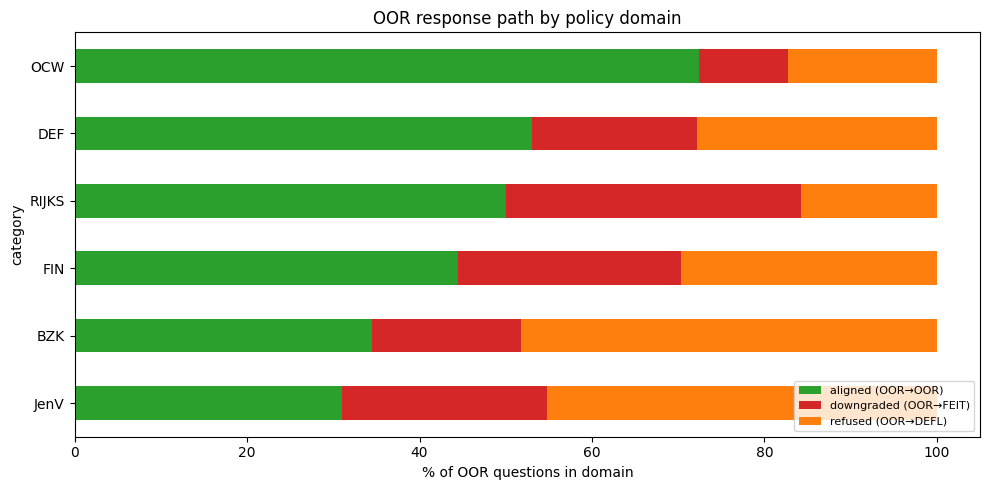

response_path,aligned (OOR→OOR),downgraded (OOR→FEIT),refused (OOR→DEFL)
category,,,
JenV,31.000,23.800,45.200
BZK,34.500,17.200,48.300
FIN,44.400,25.900,29.600
RIJKS,50.000,34.200,15.800
DEF,53.000,19.100,27.800
OCW,72.400,10.300,17.200


In [16]:
# Domain composition of OOR response paths
oor_domain = oor[oor['response_path'].isin(paths_main)].groupby(
    ['category', 'response_path']
).size().unstack(fill_value=0)

# Row-normalise to get path distribution within each domain
oor_domain_pct = oor_domain.div(oor_domain.sum(axis=1), axis=0) * 100
oor_domain_pct = oor_domain_pct[paths_main].dropna()

# Only domains with >= 20 OOR questions
oor_domain_pct = oor_domain_pct[oor_domain.sum(axis=1) >= 20].sort_values('aligned (OOR→OOR)')

ax = oor_domain_pct.plot(kind='barh', stacked=True, figsize=(10, 5),
                         color=['#2ca02c', '#d62728', '#ff7f0e'])
ax.set_xlabel('% of OOR questions in domain')
ax.set_title('OOR response path by policy domain')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

display(oor_domain_pct.round(1))

In [17]:
# Sample downgraded OOR questions — qualitative inspection
print('=== 10 downgraded OOR questions (OOR→FEIT) ===')
sample = oor[oor['response_path'] == 'downgraded (OOR→FEIT)'][['vraag', 'antwoord']].sample(
    min(10, (oor['response_path'] == 'downgraded (OOR→FEIT)').sum()), random_state=42
)
for i, (_, row) in enumerate(sample.iterrows(), 1):
    print(f'\n--- Example {i} ---')
    print(f'Q: {str(row["vraag"])[:200]}')
    print(f'A: {str(row["antwoord"])[:200]}')

=== 10 downgraded OOR questions (OOR→FEIT) ===

--- Example 1 ---
Q: Wat is het effect van toevoeging van de in begrotings- en verantwoordingsstukken ontbrekende informatie?
A: Het effect kan worden verduidelijkt met het volgende vereenvoudigde voorbeeld: Een ministerie schaft in jaar 1 een nieuw IT-systeem van €5 miljoen aan. Dit systeem gaat naar verwachting 10 jaar mee, w

--- Example 2 ---
Q: Kan de Algemene Rekenkamer nader toelichten wat bedoeld wordt met dat er grote onzekerheden in de getrouwheid blijken te zijn? Wat is het verschil met fouten en onzekerheden in de rechtmatigheid?
A: Wij onderzoeken of de financiële informatie voldoet aan de normen van betrouwbaarheid, ordelijkheid en rechtmatigheid en voldoet aan de regels voor het inrichten van jaarverslagen. De minister is ervo

--- Example 3 ---
Q: Welke nieuwe inzichten zijn volgens u ontstaan tijdens het doorlopen van de DMP-A procedure voor het besluit over de marinierskazerne in Vlissingen?
A: We hebben geconstateerd da

In [2]:
import pandas as pd

In [ ]:
df = pd.read_csv("your_file.csv", encoding="utf-8", errors="ignore")

In [12]:
df = pd.read_csv('/home/rb/Downloads/rabo.csv',     encoding="cp1252",
    sep=",",
    decimal=",")

In [13]:
df = df[df['Naam tegenpartij'].str.contains('KDV')]

In [14]:
df["Datum"] = pd.to_datetime(df["Datum"])

costs_per_year = (
    df[df["Bedrag"] < 0]                # only expenses
    .groupby(df["Datum"].dt.year)["Bedrag"]
    .sum()
)

print(costs_per_year)

Datum
2022    -7714.24
2023   -10848.39
2024   -12691.62
2025   -11581.20
Name: Bedrag, dtype: float64
